# A Linear Soft Sensor for Membrane Fouling — Seawater RO Desalination

A **soft sensor** is a model that stands in for a measurement you don't have. Real
RO plants have flow, pressure, temperature and TDS sensors around the membrane —
but they rarely measure the membrane's *water permeability* directly (it isn't a
physical sensor, it's a fitted model parameter). Yet permeability is exactly what
degrades as the membrane fouls.

The idea here: **learn the clean-membrane relationship between feed conditions and
membrane performance from a known-healthy baseline, then watch for when reality
stops matching it.**

This uses one plant's operating history — `seawater-ro-fouled` — spanning two
regimes back to back, the way a real plant's historian would actually look:

1. A **clean baseline**: the first month of operation (e.g. right after
   commissioning or the last documented cleaning), where the membrane's water
   permeability sits at its pristine value.
2. A **fouling event**: permeability then declines on a slow exponential
   trajectory as a cake layer / biofilm builds up (see
   `deployments/WATERTAP/models/seawater-ro-fouled/generate-values.py`).

We train a linear regression (with pairwise interaction terms) on the clean
baseline only, to predict **permeate flow** and **salt passage** from **feed
flow, pressure, temperature and TDS**. RO water flux is ≈ `A × driving force`,
so that regression's prediction is "what flux should be right now if the
membrane were still at its baseline permeability" — which means the ratio of
*actual* to *predicted* flow is itself a direct, physically grounded estimate of
**current permeability as a fraction of baseline**. We compute that ratio across
the plant's entire history and watch it drop. It's built entirely from ordinary
process measurements; it never sees the membrane's permeability directly.

## Setup
0. Follow the steps in [deployments/WATERTAP/README.md](../../deployments/WATERTAP/README.md) to install requirements.
1. Start the server with the shared config — it ingests `watertap-seawater-ro-fouled`
   (namespace `wbsf:`) among its sources:
   `acquirium server --config deployments/WATERTAP/scripts/acquirium.toml`
2. Connect:

In [1]:
from datetime import timedelta

from acquirium import Acquirium
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

acq = Acquirium(server_url="localhost", server_port=8000, use_ssl=False)
S223 = "http://data.ashrae.org/standard223#"
NAWI = "urn:nawi-water-ontology#"

pl.Config.set_tbl_width_chars(1000)
pl.Config.set_fmt_str_lengths(200)

polars.config.Config

## Pulling feed and permeate data — by meaning

The RO unit (`wbsf:RO`, class `nawi:ReverseOsmosisMembrane`) has one inlet
`ConnectionPoint` carrying the seawater feed, and two outlets disambiguated by
medium — the permeate is `s223:Fluid-Water`, the retentate/concentrate is
`nawi:Water-Brine`. We walk `RO -> hasConnectionPoint -> (filter by hasMedium) ->
hasProperty` to land on the sensors we want, rather than hard-coding point names —
the same query shape would work against any plant with this ontology, not just
this one.

In [2]:
def ro_stream_query(ro_uri: str, medium: str, alias: str):
    """Data observed at the RO unit's connection point carrying `medium`."""
    return (
        acq.find_entity(uri=ro_uri, alias="ro")
           .find_related(_class="ConnectionPoint", alias=f"{alias}_cp",
                         predicates=[S223 + "hasConnectionPoint"], hops=1)
           .find_related(uri=medium, alias=f"{alias}_medium", _from=f"{alias}_cp",
                         predicates=[S223 + "hasMedium"], hops=1)
           .find_data(alias=alias, _from=f"{alias}_cp")
    )


def build_dataset(ro_uri: str) -> pl.DataFrame:
    """Join feed + permeate streams for one RO unit into one wide frame."""
    feed_df = ro_stream_query(ro_uri, NAWI + "Water-Seawater", "feed").dataframe(shape="wide", cast_value="float")
    permeate_df = ro_stream_query(ro_uri, S223 + "Fluid-Water", "permeate").dataframe(shape="wide", cast_value="float")

    df = feed_df.join(permeate_df, on="time", how="inner")
    df = df.rename({c: c.split(":")[-1] for c in df.columns if c != "time"})
    df = df.rename({
        "RO-in-flow-mass-water": "feed_flow",
        "RO-in-pressure": "feed_pressure",
        "RO-in-temperature": "feed_temperature",
        "RO-in-flow-mass-tds": "feed_tds",
        "RO-out-flow-mass-water": "permeate_flow",
        "RO-out-flow-mass-tds": "permeate_tds",
    })
    # Salt passage: the fraction of feed salt mass flow that makes it into the
    # permeate (1 - salt rejection) — the standard RO salt-transport metric.
    df = df.with_columns((pl.col("permeate_tds") / pl.col("feed_tds")).alias("salt_passage"))
    return df.drop_nulls().sort("time")


df = build_dataset("wbsf:RO")
print(f"{df.shape[0]} samples, {df['time'].min()} .. {df['time'].max()}")
df.select(["feed_flow", "feed_pressure", "feed_temperature", "feed_tds", "permeate_flow", "salt_passage"]).describe()

1440 samples, 2025-01-01 00:00:00+00:00 .. 2025-03-01 23:00:00+00:00


statistic,feed_flow,feed_pressure,feed_temperature,feed_tds,permeate_flow,salt_passage
str,f64,f64,f64,f64,f64,f64
"""count""",1440.0,1440.0,1440.0,1440.0,1440.0,1440.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",306.123833,7e6,290.909338,10.387802,134.635591,0.002776
"""std""",18.564185,0.0,0.553009,0.63703,8.223108,0.000235
"""min""",266.834514,7e6,289.607352,9.008039,111.871882,0.002216
"""25%""",289.422623,7e6,290.518304,9.830932,128.45263,0.002594
"""50%""",306.327616,7e6,290.802309,10.39448,136.613945,0.002763
"""75%""",321.824628,7e6,291.220263,10.943788,141.19344,0.002958
"""max""",352.910047,7e6,292.772753,11.969872,149.270172,0.003323


One thing stands out: `feed_pressure` has **zero variance** — this plant runs its
high-pressure pump at a fixed 70 bar setpoint (`P1.control_volume.properties_out[0].pressure`
is fixed in `flowsheet.py`, not one of `generate-values.py`'s varying drivers). We
keep it in the feature set as requested, but a regression can't extract signal
from a constant — its column is exactly its mean in every row, so it folds into
the intercept and contributes nothing beyond that. That's a realistic soft-sensor
caveat, not a bug: real plants often hold one operating variable fixed by control,
and you can't learn its effect from historical data that never varied it.

## Split by time, not by source

Everything above is one continuous series from one plant. The split that matters
is **when**, not *which dataset*: we'll treat the plant's first month of
operation as a known-clean baseline and train on that alone, then score the
trained model across the plant's entire history — clean baseline and fouling
event together — the way you'd actually deploy a soft sensor against a live
historian.

In [3]:
BASELINE_DAYS = 30  # assumed known-clean window: the plant's first month of operation
baseline_end = df["time"][0] + timedelta(days=BASELINE_DAYS)

baseline = df.filter(pl.col("time") < baseline_end)
print(f"baseline (training pool): {baseline.shape[0]} samples, "
      f"{baseline['time'].min()} .. {baseline['time'].max()}")
print(f"full history (scored):    {df.shape[0]} samples, "
      f"{df['time'].min()} .. {df['time'].max()}")

baseline (training pool): 720 samples, 2025-01-01 00:00:00+00:00 .. 2025-01-30 23:00:00+00:00
full history (scored):    1440 samples, 2025-01-01 00:00:00+00:00 .. 2025-03-01 23:00:00+00:00


## The model: OLS with pairwise interaction terms

A "linear model with interaction terms" here means: standardize each feature
(zero mean, unit variance, using **training-set statistics only**), then regress
on the 4 main effects plus all 6 pairwise products
(`feed_flow×feed_pressure`, `feed_flow×feed_temperature`, …) — 11 coefficients
plus an intercept, fit by ordinary least squares. This captures things like "the
pressure sensitivity of permeate flow depends on temperature" without jumping to
a black-box model — everything here is still a closed-form linear fit, just over
an enriched feature set.

In [4]:
FEATURES = ["feed_flow", "feed_pressure", "feed_temperature", "feed_tds"]


class InteractionOLS:
    """OLS on standardized main effects + all pairwise interaction terms."""

    def __init__(self, features):
        self.features = features

    def _design(self, X):
        Xs = (X - self.mean_) / self.std_
        cols = [np.ones(len(Xs))] + [Xs[:, i] for i in range(Xs.shape[1])]
        for i in range(Xs.shape[1]):
            for j in range(i + 1, Xs.shape[1]):
                cols.append(Xs[:, i] * Xs[:, j])
        return np.column_stack(cols)

    def fit(self, X, y):
        self.mean_ = X.mean(axis=0)
        std = X.std(axis=0)
        self.std_ = np.where(std == 0, 1.0, std)  # constant feature -> zero column, not NaN
        D = self._design(X)
        self.coef_, *_ = np.linalg.lstsq(D, y, rcond=None)
        resid = y - D @ self.coef_
        self.train_resid_std_ = resid.std()
        ss_res, ss_tot = (resid ** 2).sum(), ((y - y.mean()) ** 2).sum()
        self.r2_ = 1 - ss_res / ss_tot
        return self

    def predict(self, X):
        return self._design(X) @ self.coef_

## Train on the clean baseline only

An 80/20 split of the baseline window (shuffled, since there's no fouling trend to
leak across a time split *within* this window — every sample in it is equally
"clean") checks that the fit generalizes before we ever score it against the rest
of the plant's history.

In [5]:
rng = np.random.RandomState(0)
n = baseline.shape[0]
idx = rng.permutation(n)
split = int(n * 0.8)
train_idx, test_idx = idx[:split], idx[split:]

X_baseline = baseline.select(FEATURES).to_numpy()
y_flow = baseline["permeate_flow"].to_numpy()
y_salt = baseline["salt_passage"].to_numpy()

model_flow = InteractionOLS(FEATURES).fit(X_baseline[train_idx], y_flow[train_idx])
model_salt = InteractionOLS(FEATURES).fit(X_baseline[train_idx], y_salt[train_idx])


def r2(y_true, y_pred):
    return 1 - ((y_true - y_pred) ** 2).sum() / ((y_true - y_true.mean()) ** 2).sum()


print("permeate flow   -- train R2: %.5f   held-out R2: %.5f   train residual std: %.4f kg/s"
      % (model_flow.r2_, r2(y_flow[test_idx], model_flow.predict(X_baseline[test_idx])), model_flow.train_resid_std_))
print("salt passage    -- train R2: %.5f   held-out R2: %.5f   train residual std: %.2e"
      % (model_salt.r2_, r2(y_salt[test_idx], model_salt.predict(X_baseline[test_idx])), model_salt.train_resid_std_))

permeate flow   -- train R2: 0.99109   held-out R2: 0.98961   train residual std: 0.3433 kg/s
salt passage    -- train R2: 0.99948   held-out R2: 0.99937   train residual std: 4.80e-06


Both targets fit almost perfectly (R² > 0.98) on held-out baseline data —
expected, since permeate flow and salt passage really are (near-)deterministic
functions of feed conditions when the membrane itself isn't changing. That tight
fit is exactly what makes the soft sensor useful: the training residual is small
relative to the ~30% flux decline fouling eventually causes, so a real drop in
permeability will stand out clearly against it.

## Estimating permeability across the plant's entire history

We feed the *whole* time series — baseline and fouling event together — through
`model_flow`. It was never told fouling exists, and it never sees anything past
the first month during training, so its prediction at every point is "expected
flux if the membrane were still at baseline." The ratio of actual to predicted
flow is then a direct estimate of **relative permeability**: ≈1.0 while the
membrane is clean, dropping as it fouls. We smooth it with a short rolling mean
(a ratio of two noisy quantities is noisier than either alone) and keep
`model_salt`'s residual as a secondary, corroborating signal rather than a
primary detector.

In [6]:
X_all = df.select(FEATURES).to_numpy()

pred_flow = model_flow.predict(X_all)
pred_salt = model_salt.predict(X_all)

relative_permeability_raw = df["permeate_flow"].to_numpy() / pred_flow

SMOOTH_SAMPLES = 6  # 6-hour trailing rolling mean to tame ratio noise
relative_permeability = (
    pl.Series(relative_permeability_raw)
      .rolling_mean(window_size=SMOOTH_SAMPLES, min_samples=1)
      .to_numpy()
)

# Salt passage residual, kept as a secondary corroborating signal (not the detector).
resid_salt = df["salt_passage"].to_numpy() - pred_salt
z_salt = resid_salt / model_salt.train_resid_std_

df = df.with_columns([
    pl.Series("predicted_permeate_flow", pred_flow),
    pl.Series("relative_permeability_raw", relative_permeability_raw),
    pl.Series("relative_permeability", relative_permeability),
    pl.Series("z_salt", z_salt),
])
df.select(["time", "permeate_flow", "predicted_permeate_flow", "relative_permeability", "z_salt"]).head(3)

time,permeate_flow,predicted_permeate_flow,relative_permeability,z_salt
"datetime[μs, UTC]",f64,f64,f64,f64
2025-01-01 00:00:00 UTC,138.968712,138.751001,1.001569,0.462107
2025-01-01 01:00:00 UTC,135.245735,135.163186,1.00109,0.333798
2025-01-01 02:00:00 UTC,133.821564,133.770426,1.000854,0.772506


## Detecting the onset

A single noisy sample crossing a threshold isn't a detection — we require the
smoothed relative-permeability estimate to stay below a **4σ band around the
baseline's own noise for 3 consecutive hourly samples** before calling it an
anomaly, a simple sustained-exceedance rule (the same pattern as before, just
retargeted from an abstract z-score onto the permeability estimate itself).

In [7]:
K_SIGMA = 4.0
SUSTAIN_SAMPLES = 3  # 3 consecutive hourly samples

baseline_rel_perm = relative_permeability[: baseline.shape[0]]
baseline_mean = baseline_rel_perm.mean()
baseline_std = baseline_rel_perm.std()
threshold = baseline_mean - K_SIGMA * baseline_std

below = relative_permeability < threshold
sustained = np.convolve(below.astype(int), np.ones(SUSTAIN_SAMPLES, dtype=int), mode="valid") == SUSTAIN_SAMPLES
onset_idx = int(np.argmax(sustained)) if sustained.any() else None

print(f"baseline relative permeability: {baseline_mean:.4f} +/- {baseline_std:.4f}   (threshold: {threshold:.4f})")
if onset_idx is not None:
    onset_time = df["time"][onset_idx]
    elapsed = onset_time - df["time"][0]
    print(f"Sustained drop detected at {onset_time}  ({elapsed} into the run)")
    print(f"relative permeability at onset: {relative_permeability[onset_idx]:.3f}   "
          f"(vs. {relative_permeability[-24:].mean():.3f} by the end of the run)")
else:
    print("No sustained drop detected.")

baseline relative permeability: 1.0000 +/- 0.0010   (threshold: 0.9962)
Sustained drop detected at 2025-01-31 23:00:00+00:00  (30 days, 23:00:00 into the run)
relative permeability at onset: 0.996   (vs. 0.850 by the end of the run)


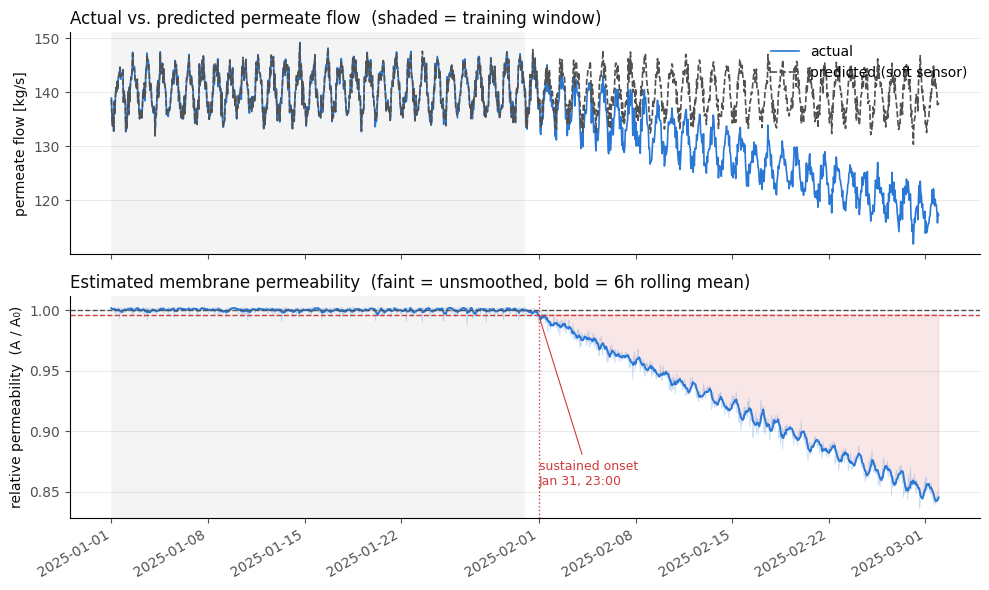

In [8]:
fig, (ax_flow, ax_perm) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
BLUE = "#2a78d6"
CRITICAL = "#d03b3b"

t = df["time"].to_list()

for ax in (ax_flow, ax_perm):
    ax.axvspan(t[0], baseline_end, color=INK_SECONDARY, alpha=0.06, linewidth=0)

ax_flow.plot(t, df["permeate_flow"], color=BLUE, linewidth=1.2, label="actual")
ax_flow.plot(t, df["predicted_permeate_flow"], color=INK_SECONDARY, linewidth=1.2,
             linestyle="--", label="predicted (soft sensor)")
ax_flow.set_ylabel("permeate flow [kg/s]", color=INK_PRIMARY)
ax_flow.legend(frameon=False, loc="upper right")
ax_flow.set_title("Actual vs. predicted permeate flow  (shaded = training window)",
                   color=INK_PRIMARY, loc="left")

ax_perm.plot(t, relative_permeability_raw, color=BLUE, linewidth=0.6, alpha=0.25)
ax_perm.plot(t, relative_permeability, color=BLUE, linewidth=1.4)
ax_perm.axhline(1.0, color=INK_SECONDARY, linewidth=1, linestyle="--")
ax_perm.axhline(threshold, color=CRITICAL, linewidth=1, linestyle="--")
ax_perm.fill_between(t, threshold, relative_permeability, where=(relative_permeability < threshold),
                      color=CRITICAL, alpha=0.12, interpolate=True)
if onset_idx is not None:
    ax_perm.axvline(t[onset_idx], color=CRITICAL, linewidth=1, linestyle=":")
    ax_perm.annotate(f"sustained onset\n{onset_time:%b %d, %H:%M}",
                      xy=(t[onset_idx], threshold), xycoords="data",
                      xytext=(t[onset_idx], 0.15), textcoords=("data", "axes fraction"),
                      color=CRITICAL, fontsize=9,
                      arrowprops=dict(arrowstyle="-", color=CRITICAL, linewidth=0.8))
ax_perm.set_ylabel("relative permeability  (A / A₀)", color=INK_PRIMARY)
ax_perm.set_title("Estimated membrane permeability  (faint = unsmoothed, bold = 6h rolling mean)",
                   color=INK_PRIMARY, loc="left")

for ax in (ax_flow, ax_perm):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", color=INK_SECONDARY, alpha=0.15, linewidth=0.6)
    ax.tick_params(colors=INK_SECONDARY)

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## Validation only: does the estimate actually track fouling?

The soft sensor never sees the membrane's water permeability (`A_comp`) — that's
the point, a real plant wouldn't have it either. But *this* plant is a WaterTAP
simulation, so we can pull `A_comp` purely to check the estimate against the
real thing (and to see how much lag there was between the fouling event actually
starting and the sustained-exceedance rule catching it) rather than to build the
detector itself.

In [9]:
a_comp_df = (
    acq.find_entity(uri="wbsf:RO", alias="ro")
       .find_data(alias="a_comp", _from="ro")
       .dataframe(shape="wide", cast_value="float")
)
a_comp_col = [c for c in a_comp_df.columns if "permeability" in c][0]
a_comp_df = a_comp_df.select(["time", a_comp_col]).rename({a_comp_col: "A_comp"})

df_v = df.join(a_comp_df, on="time", how="inner")
A = df_v["A_comp"].to_numpy()
baseline_A = df_v.filter(pl.col("time") < baseline_end)["A_comp"].to_numpy()
A0_est = baseline_A.mean()  # baseline mean, not a single noisy sample

# True relative permeability, smoothed the same way as the estimate, so the
# comparison below is apples-to-apples.
true_relative_permeability = (
    pl.Series(A / A0_est)
      .rolling_mean(window_size=SMOOTH_SAMPLES, min_samples=1)
      .to_numpy()
)

corr = np.corrcoef(df_v["relative_permeability"].to_numpy(), true_relative_permeability)[0, 1]
mae = np.abs(df_v["relative_permeability"].to_numpy() - true_relative_permeability).mean()
print(f"correlation(estimated, true relative permeability) = {corr:.4f}")
print(f"mean absolute error = {mae:.4f}  (in units of A/A0, e.g. 0.01 = 1 percentage point)")

# True onset: same sustained-exceedance rule (K_SIGMA, SUSTAIN_SAMPLES), applied
# to the telemetry instead of the estimate, for a fair comparison.
true_baseline = true_relative_permeability[: baseline.shape[0]]
true_threshold = true_baseline.mean() - K_SIGMA * true_baseline.std()
true_below = true_relative_permeability < true_threshold
true_sustained = np.convolve(true_below.astype(int), np.ones(SUSTAIN_SAMPLES, dtype=int), mode="valid") == SUSTAIN_SAMPLES
true_onset_idx = int(np.argmax(true_sustained)) if true_sustained.any() else None
true_onset_time = df_v["time"][true_onset_idx] if true_onset_idx is not None else None

if onset_idx is not None and true_onset_time is not None:
    lag_hours = (onset_time - true_onset_time).total_seconds() / 3600
    print(f"true fouling onset (A_comp crosses the same threshold rule): {true_onset_time}")
    print(f"detected onset (from the soft sensor's permeability estimate): {onset_time}")
    if lag_hours >= 0:
        print(f"detection lag: {lag_hours:.1f} hours AFTER the ground-truth crossing")
    else:
        print(f"detection lag: {-lag_hours:.1f} hours BEFORE the ground-truth crossing")

correlation(estimated, true relative permeability) = 0.9981
mean absolute error = 0.0403  (in units of A/A0, e.g. 0.01 = 1 percentage point)
true fouling onset (A_comp crosses the same threshold rule): 2025-01-31 23:00:00+00:00
detected onset (from the soft sensor's permeability estimate): 2025-01-31 23:00:00+00:00
detection lag: 0.0 hours AFTER the ground-truth crossing


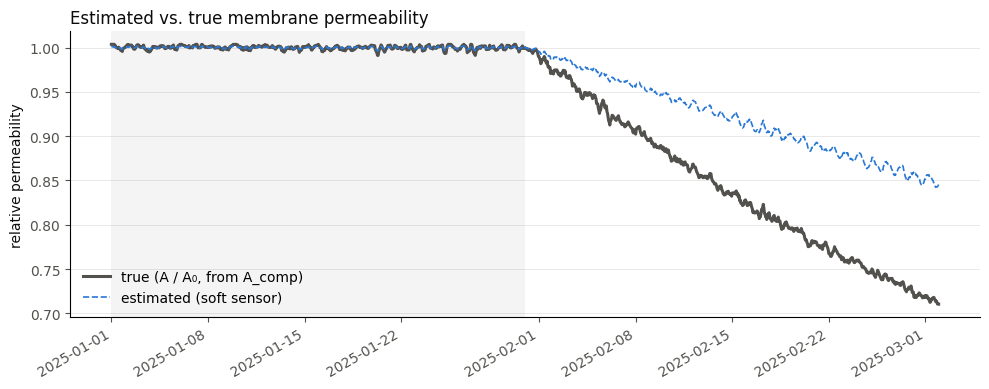

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.axvspan(t[0], baseline_end, color=INK_SECONDARY, alpha=0.06, linewidth=0)
ax.plot(t, true_relative_permeability, color=INK_SECONDARY, linewidth=2.2, label="true (A / A₀, from A_comp)")
ax.plot(t, df_v["relative_permeability"], color=BLUE, linewidth=1.2, linestyle="--",
        label="estimated (soft sensor)")
ax.set_ylabel("relative permeability", color=INK_PRIMARY)
ax.set_title("Estimated vs. true membrane permeability", color=INK_PRIMARY, loc="left")
ax.legend(frameon=False, loc="lower left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", color=INK_SECONDARY, alpha=0.15, linewidth=0.6)
ax.tick_params(colors=INK_SECONDARY)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

The estimate tracks the true curve closely at first, then runs increasingly
*conservative* as fouling deepens: by the end of the run the true membrane is at
~71% of baseline (from `A_comp`) while the estimate reads ~85%. The timing is
still right — onset detection landed on the same hour as the ground truth — but
the magnitude understates severity once the drop gets large. That's the
`flux ≈ A × driving force` approximation breaking down, not noise: real RO flux
is `A × (ΔP − Δπ)`, and as A falls, flux falls, which *reduces* concentration
polarization at the membrane wall and therefore the osmotic pressure penalty
Δπ — so the driving force partially compensates the permeability loss. Our
linear approximation doesn't know about that feedback, so it underestimates how
much A has actually dropped once the effect is large. A production version
would fit that correction (or a small nonlinear term) using plant data spanning
a full fouling-to-cleaning cycle rather than assuming pure proportionality.

That's also why the timing detection stayed accurate even though the magnitude
didn't: catching a *change* only needs the ratio to move consistently in one
direction, not to be exactly calibrated. The salt-passage residual (`z_salt`,
computed above but not used for detection) moves the same direction too,
corroborating the story from a second, independent channel.

This version trades a little detection speed for being directly interpretable:
it only uses one channel (flow) instead of the combined two-channel score from
an earlier pass at this notebook, so it's a slightly weaker statistical test —
but "our membrane is at ~85% of baseline and falling" is something an operator
can act on immediately (even if the true number is a bit lower), where an
abstract z-score isn't.

That's the soft-sensor pattern in one notebook: **a model trained on a
known-clean baseline, inverted through the underlying physics (flux ≈ A × driving
force), turns into a continuously updated estimate of the thing you can't
measure directly** — right on timing, approximate on magnitude, scored against
the plant's ordinary operating history, without ever needing a sensor for the
thing that's actually failing.

A production version would replace "the first month of operation" with
"since the last documented cleaning" on real plant data, and would tune
`K_SIGMA`, `SUSTAIN_SAMPLES` and the smoothing window against a labeled
maintenance history instead of eyeballing a simulation.